# Benchmark

## 1. Environment

In [1]:
import cfe
import scanpy as sc
import pandas as pd

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")

[08/14/2025 06:16:49] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

## 2. Data

In [2]:
# sample 500 cells from pancreas dataset in scvelo
fadata = cfe.data.read_pancrease(n_obs=500)
fadata

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

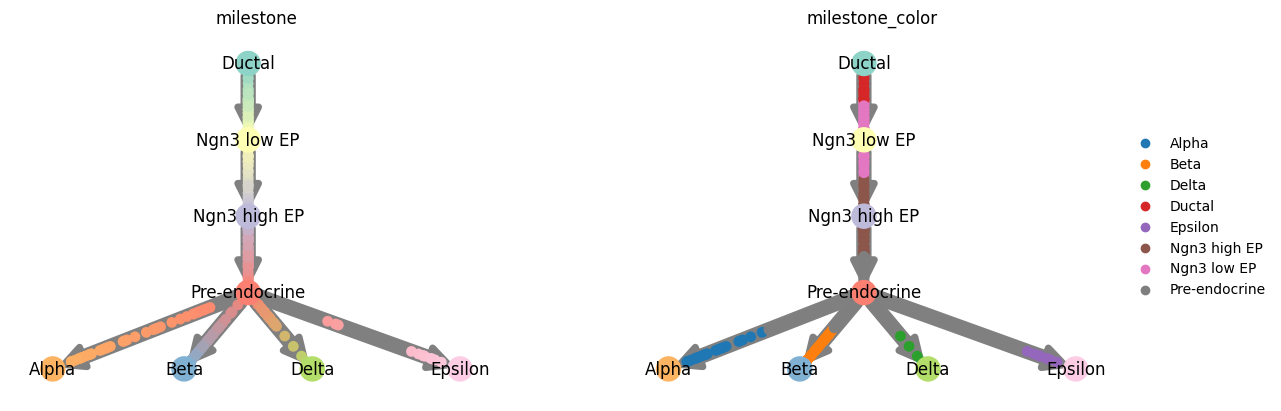

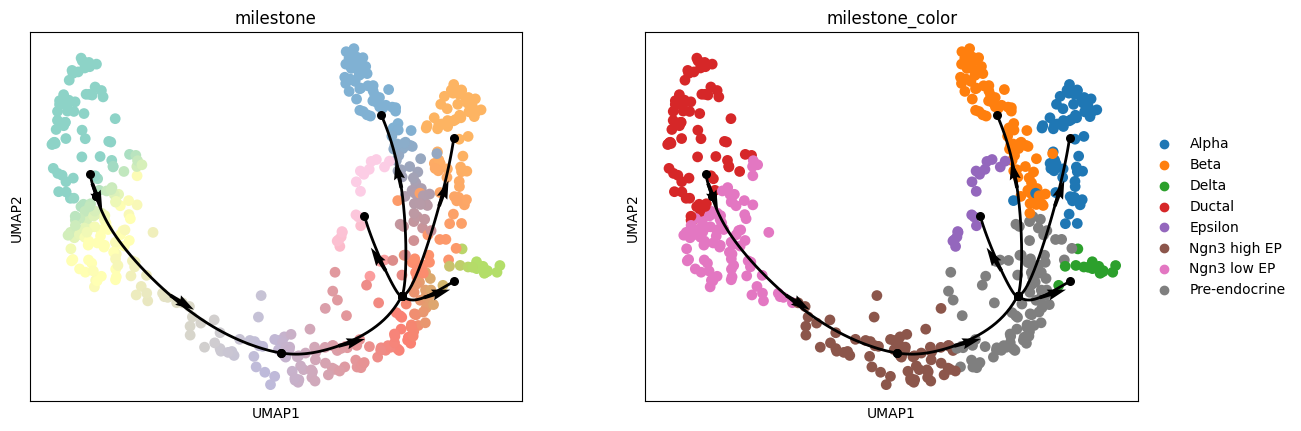

In [3]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

## 3. Method

In [4]:
# common preprocessing
import scvelo as scv

scv.pp.filter_and_normalize(fadata, min_shared_counts=20, n_top_genes=2000)
scv.pp.moments(fadata, n_pcs=20, n_neighbors=10)
fadata

Filtered out 24737 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:09) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


AnnData object with n_obs × n_vars = 500 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'cfe', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict', 'log1p', 'neighbors'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'

[08/14/2025 06:17:21] INFO     Loaded function: <function cf_paga at 0x7c159929f9a0> from /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_paga.py                     
                      INFO     method_backend: FunctionBackend: function_name-cf_paga                                                                                                                   


[08/14/2025 06:17:28] INFO     Loaded function: <function cf_comp1 at 0x7c1588292950> from /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_comp1.py                   
[08/14/2025 06:17:29] INFO     method_backend: FunctionBackend: function_name-cf_comp1                                                                                                                  
[08/14/2025 06:17:33] INFO     Loaded function: <function cf_angle at 0x7c1588215f30> from /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_angle.py                   
[08/14/2025 06:17:34] INFO     method_backend: FunctionBackend: function_name-cf_angle                                                                                                                  
[08/14/2025 06:17:38] INFO     Loaded function: <function cf_state_comp at 0x7c1580596560> from /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_state_comp.py     

  0%|          | 0/500 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
or is corrupted (e.g. due to subsetting). Consider recomputing with `pp.neighbors`.
computing terminal states
    identified 4 regions of root cells and 2 regions of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


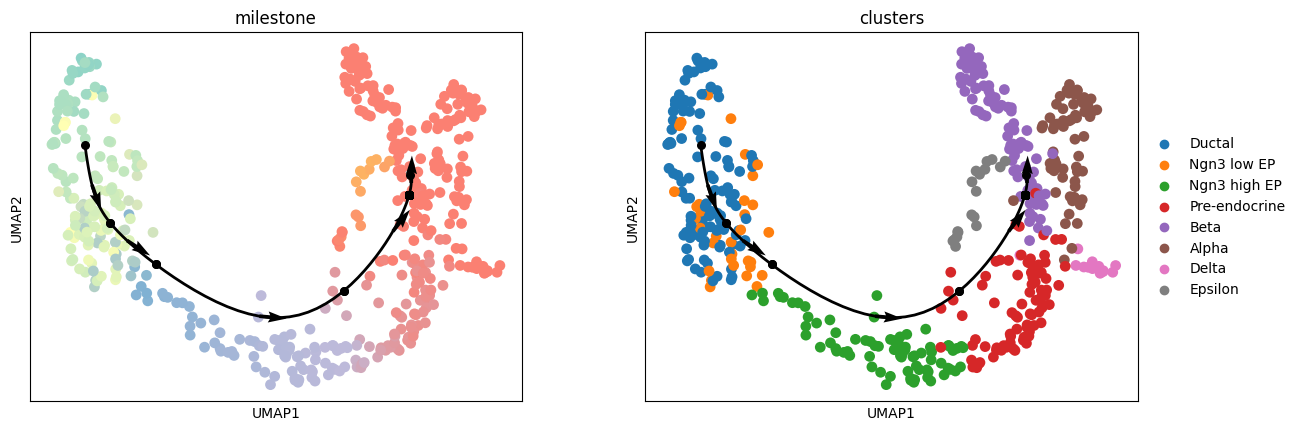

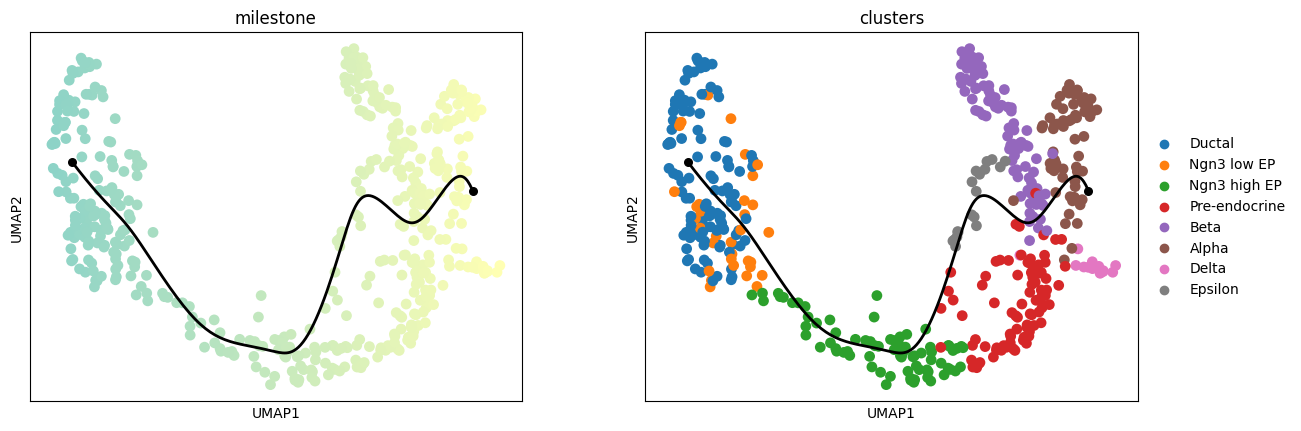

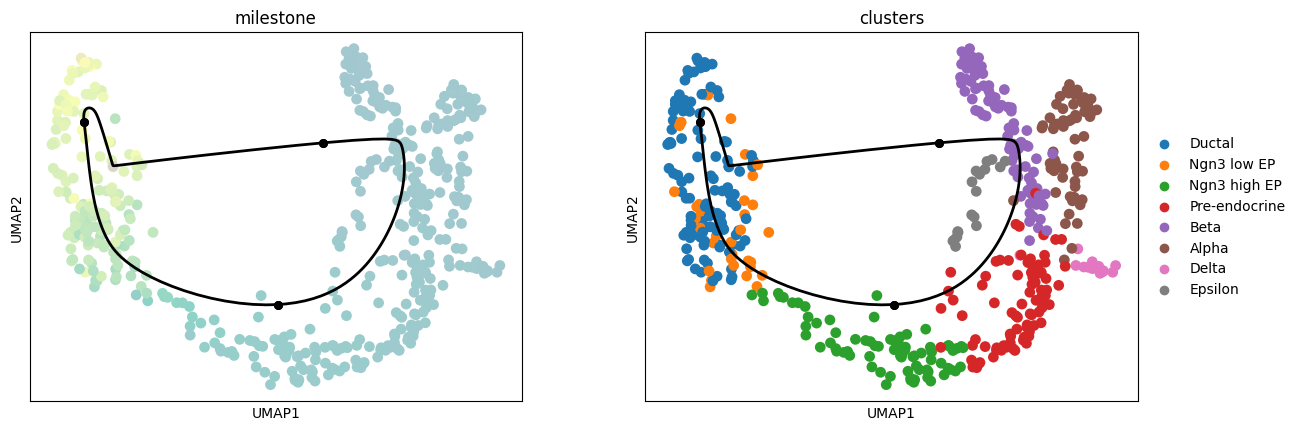

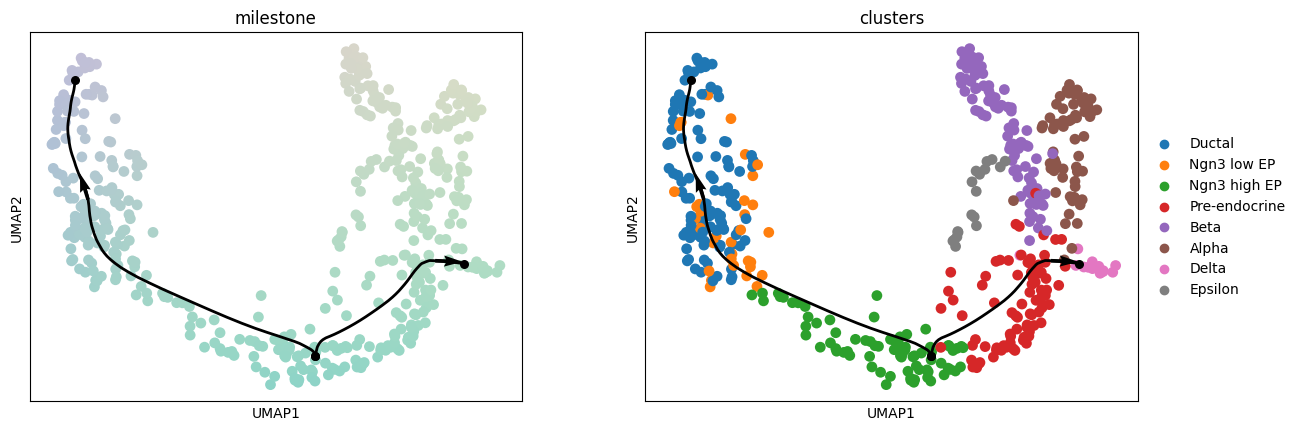

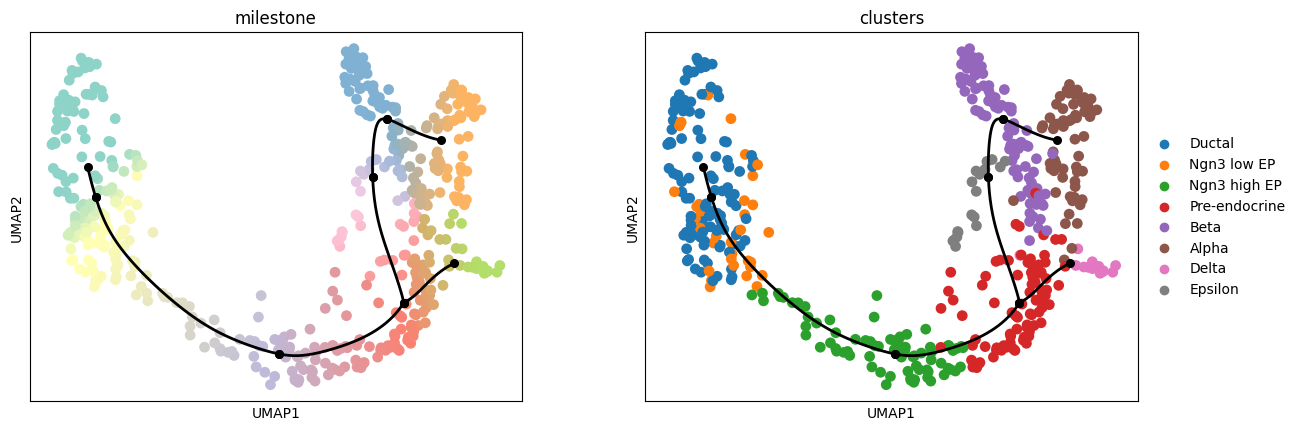

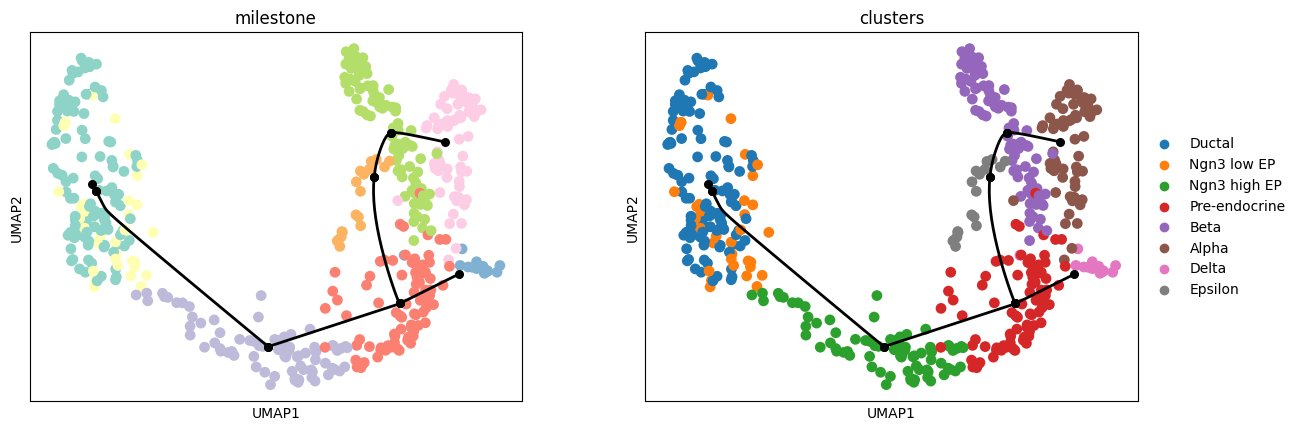

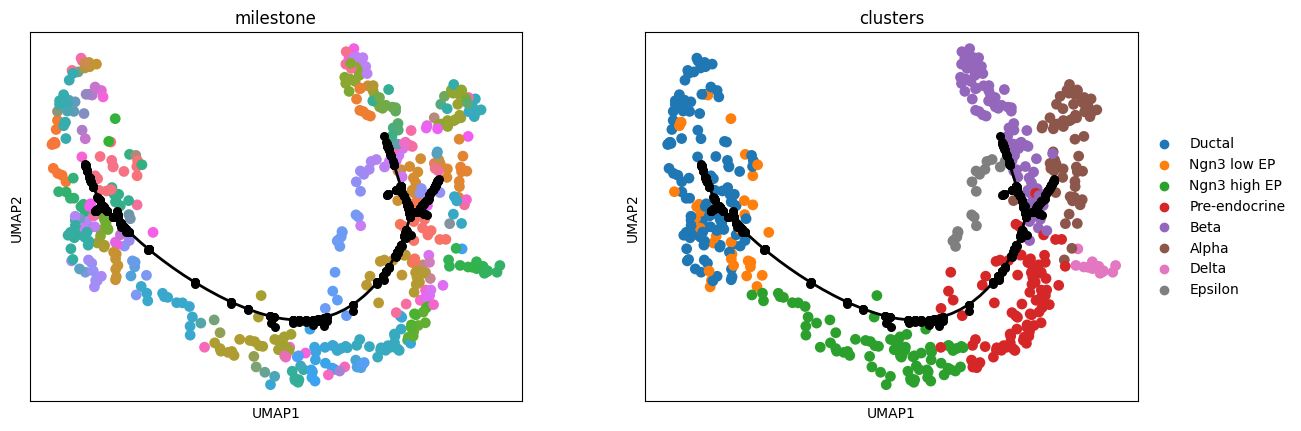

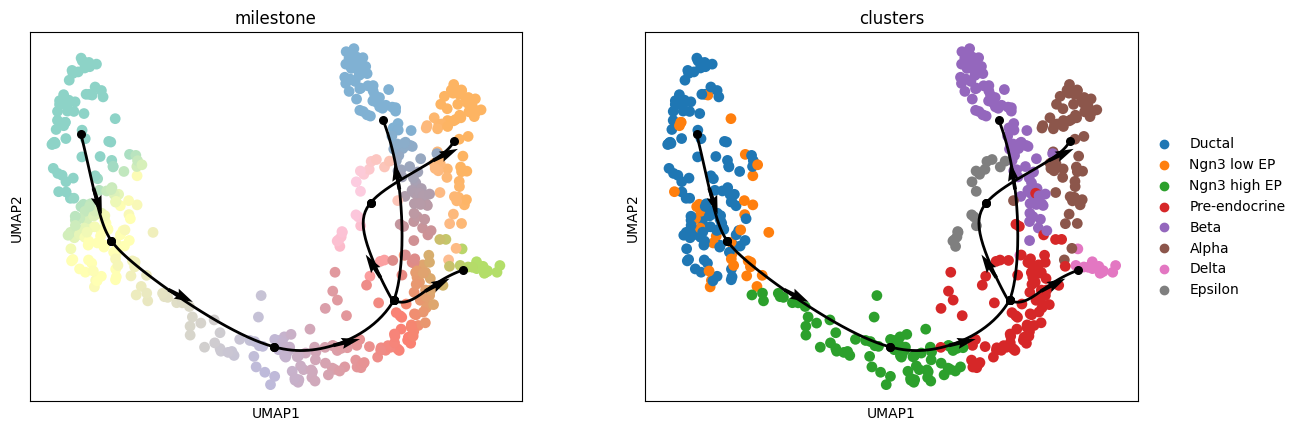

In [ ]:
cluster_key = "clusters"
cluster_key_list = ["milestone", cluster_key]


method2parameters = {
    "paga": {
        "start_id": "cell_478",
        "cluster_key": cluster_key,
        "connectivity_cutoff": 0.1,
    },
    "comp1": {
        "basis": "X_umap",
    },
    "angle" : {
        "pca_ndim": 10,
    },
    "state_comp" : {
        "basis": "X_umap",
        "n_comps": 2, # should letter than basis
    },
    "projection_mst": {
        "basis": "X_umap",
        "recluster": False,
        "cluster_key": cluster_key,
    },
    "cluster_mst": {
        "basis": "X_umap",
        "recluster": False,
        "cluster_key": cluster_key,
    },
    "graph_mst": {
        # test paramter update
        "neighbors_kwargs":{
            "n_pcs": 2,
            "n_neighbors": 5, # more clear graph
            "use_rep": "X_umap",
        }
    },
    "scvelo": {
    },
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = False
    method = cfe.method.FateMethod(method_name=method_name)
    method(fadata, **parameters) # __call__
    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

Show model name

In [6]:
parsed_model_name_list = fadata.get_all_model_name() # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[08/14/2025 06:19:04] WARNING  'ref' is not a valid random_time_string, don't need parse                                                                                                                


(['ref',
  'paga-python_function',
  'comp1-python_function',
  'angle-python_function',
  'state_comp-python_function',
  'projection_mst-python_function',
  'cluster_mst-python_function',
  'graph_mst-python_function',
  'scvelo-python_function'],
 ['ref',
  '20250814_181721__paga-python_function__8OFmpOtXll',
  '20250814_181729__comp1-python_function__GH3VfrLR81',
  '20250814_181734__angle-python_function__WZ45eNud2O',
  '20250814_181738__state_comp-python_function__PWhQ3E6sTT',
  '20250814_181746__projection_mst-python_function__ymqFt0fUZY',
  '20250814_181750__cluster_mst-python_function__tCiv1Qf3eG',
  '20250814_181754__graph_mst-python_function__SarqH1vzHD',
  '20250814_181816__scvelo-python_function__QQNWsdY10k'])

## 4. Metric

Available metrics:

In [7]:
cfe.metric.metrics

,metric_id,plotmath,latex,html,long_name,category,type,perfect,worst,symmetric
0,correlation,cor[dist],\mathit{cor}_{\textrm{dist}},cor<sub>dist</sub>,Geodesic distance correlation,cell positions,specific,1,0.0,True
1,rf_mse,MSE[rf],\mathit{MSE}_{\textit{rf}},MSE<sub>rf</sub>,Random Forest MSE,neighbourhood,specific,0,0.3,False
2,rf_nmse,NMSE[rf],\mathit{NMSE}_{\textit{rf}},NMSE<sub>rf</sub>,Random Forest Normalised MSE,neighbourhood,specific,1,0.0,False
3,rf_rsq,R[rf]^2,R^{2}_{rf},R<sup>2</sup><sub>rf</sub>,Random Forest R²,neighbourhood,specific,1,0.0,False
4,lm_nmse,NMSE[lm],\mathit{NMSE}_{\textit{lm}},NMSE<sub>lm</sub>,Linear regression Normalised MSE,neighbourhood,specific,1,0.0,False
5,lm_mse,MSE[lm],\mathit{MSE}_{\textit{lm}},MSE<sub>lm</sub>,Linear regression MSE,neighbourhood,specific,0,0.3,False
6,lm_rsq,R[lm]^2,R^{2}_{lm},R<sup>2</sup><sub>lm</sub>,Linear regression R²,neighbourhood,specific,1,0.0,False
7,edge_flip,edgeflip,\textrm{edgeflip},edgeflip,Edge flip,topology,specific,1,0.0,True
8,him,HIM,\textrm{HIM},HIM,Hamming-Ipsen-Mikhailov similarity,topology,specific,1,0.0,True
9,isomorphic,isomorphic,\textrm{isomorphic},Isomorphic,isomorphic,topology,specific,1,0.0,True


Methods are chosen to be calculated

In [8]:
implemented = [
    "correlation",
    "rf_mse", "rf_rsq", "rf_nmse",
    "lm_mse", "lm_rsq", "lm_nmse",
    "edge_flip", "him",
    # feature importance need to be fixed
    # "featureimp_cor", "featureimp_wcor",
    # "featureimp_ks", "featureimp_wilcox",
    "F1_branches", "F1_milestones"
]
implemented

['correlation',
 'rf_mse',
 'rf_rsq',
 'rf_nmse',
 'lm_mse',
 'lm_rsq',
 'lm_nmse',
 'edge_flip',
 'him',
 'F1_branches',
 'F1_milestones']

Metric calculation

In [12]:
models = list(fadata.uns["cfe"]["trajectory_history_dict"].keys())
models = parsed_model_name_list

# 4. 确保每个模型都有 waypoint_wrapper
for m in set(models) | {"ref"}:
    fadata.model_name = m
    if not fadata.is_wrapped_with_waypoints:
        fadata.add_waypoints()
# 4. 针对每个方法，调用 calculate_metrics 并收集结果
records = {}
for model in models:
    if model == "angle":
        continue
    # 跳过参考自身（ref vs ref）若不想算，可以加 if model=="ref": continue
    print(f"Calculating metrics for model: {model}")
    res = cfe.metric.calculate_metrics(
        fadata,
        now_model=model,
        ref_model="ref",
        simplify=False,  # 是否简化结果
        metrics=implemented
    )
    # 把可能缺失的指标填成 NaN
    for m in implemented:
        res.setdefault(m, float("nan"))
    records[model] = res

# 5. 构造成 DataFrame
df = pd.DataFrame.from_dict(records, orient="index", columns=implemented)

# 6. （可选）把行索引改成更可读的名字，或保存到文件
df.index.name = "method"
df

Calculating metrics for model: ref
Calculating metrics for model: 20250814_181721__paga-python_function__8OFmpOtXll


ValueError: Prediction model '20250814_181721__paga-python_function__8OFmpOtXll' has no milestone_wrapper